In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

In [49]:
attack_df = pd.read_csv("../data/clean_data/modeling_data.csv")
attack_df.drop(["country", "time", "month", "hemisphere", "species"], axis=1, inplace=True)
print(f"Num attacks: {len(attack_df)}")

attack_df.head()

Num attacks: 3367


,state,activity,fatal,season
0,florida,swimming,N,summer
1,new south wales,swimming,N,winter
2,florida,swimming,N,summer
3,western australia,dive fishing,Y,winter
4,new south wales,surfing/bodyboarding,N,fall


In [50]:
# turn fatal into binary variable
attack_df["fatal"] = (attack_df["fatal"] == "Y").astype(int)

# only keep largest activities
activities_to_keep = ["surfing/bodyboarding", "swimming", "wading"]
attack_df = attack_df[attack_df["activity"].isin(activities_to_keep)]

# drop rows where no season data
attack_df = attack_df.dropna(subset=["season"])

# compute overall statistics
total_attacks = len(attack_df)
total_fatal = len(attack_df[attack_df["fatal"] == 1])
total_nonfatal = len(attack_df[attack_df["fatal"] == 0])
prop_fatal = total_fatal / total_attacks

print(f"Total number of attacks: {total_attacks}")
print(f"Number of fatal attacks: {total_fatal}")
print(f"Number of nonfatal attacks: {total_nonfatal}")
print(f"Overall fatality rate: {prop_fatal:.2%}\n")
attack_df.head()

Total number of attacks: 2339
Number of fatal attacks: 329
Number of nonfatal attacks: 2010
Overall fatality rate: 14.07%



,state,activity,fatal,season
0,florida,swimming,0,summer
1,new south wales,swimming,0,winter
2,florida,swimming,0,summer
4,new south wales,surfing/bodyboarding,0,fall
5,hawaii,surfing/bodyboarding,0,spring


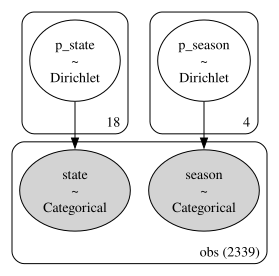

In [52]:
coords = {
    "alts_intercepts": ["surfing/bodyboarding", "swimming"],
    "alts_probs": ["surfing/bodyboarding", "swimming", "wading"],
    "obs": np.arange(len(attack_df))
}

state_data, state_names = pd.factorize(attack_df["state"])
season_data, season_names = pd.factorize(attack_df["season"])

with pm.Model(coords=coords) as model:

    # fatal_obs = pm.Data("fatal", attack_df["fatal"], dims="obs")

    p_state = pm.Dirichlet("p_state", a=np.ones(len(state_names)))
    state = pm.Categorical("state", p=p_state, observed=state_data, dims="obs")

    p_season = pm.Dirichlet("p_season", a=np.ones(len(season_names)))
    season = pm.Categorical("season", p=p_season, observed=season_data, dims="obs")

    

pm.model_to_graphviz(model)


In [56]:
with model:
  idata = pm.sample(random_seed=5650)

  pm.sample_posterior_predictive(idata, extend_inferencedata=True)

idata.posterior_predictive["state"]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_state, p_season]


/Users/ian.alvarado/Georgetown/DSAN5650/5650-final-project/.venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [season, state]


/Users/ian.alvarado/Georgetown/DSAN5650/5650-final-project/.venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

<xarray.DataArray 'state' (chain: 4, draw: 1000, obs: 2339)> Size: 75MB
array([[[14,  6,  8, ...,  0,  6,  1],
        [ 0,  4,  7, ...,  0,  0,  1],
        [ 2,  5,  4, ...,  5, 12,  2],
        ...,
        [ 0,  0,  7, ...,  0,  9,  1],
        [12,  0,  0, ...,  0, 14,  0],
        [ 0,  0,  8, ...,  1,  3,  9]],

       [[ 8,  6,  0, ...,  9,  0, 11],
        [ 6, 16,  8, ...,  2, 16,  2],
        [ 2,  0, 12, ...,  4,  9,  0],
        ...,
        [ 0,  8,  0, ...,  0,  0, 16],
        [ 6,  8,  6, ...,  1, 12,  0],
        [ 0,  6,  0, ...,  4, 11,  0]],

       [[ 1,  2,  4, ..., 12,  4,  4],
        [ 1, 14, 11, ...,  6,  6,  5],
        [ 0, 14,  0, ..., 11,  1,  4],
        ...,
        [ 0,  0,  6, ...,  0, 16,  2],
        [ 8,  4,  0, ...,  6,  1, 13],
        [ 2,  0,  6, ...,  0, 11,  0]],

       [[ 6,  4,  0, ...,  0,  0, 14],
        [ 0,  9,  9, ..., 10, 11,  1],
        [12,  0,  0, ...,  1, 15, 13],
        ...,
        [15, 14, 14, ...,  0,  0,  2],
        [ 4,  4,  0, ...,  0, 16, 15],
        [ 0,  0,  0, ..., 14, 11, 16]]], shape=(4, 1000, 2339))
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * obs      (obs) int64 19kB 0 1 2 3 4 5 6 ... 2333 2334 2335 2336 2337 2338